# Aesha's Contribution in DDPM

### Imports and Setup

In [1]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


### Define Transform & Load Dataset

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# Normalize to [-1, 1] for DDPM
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset_path = "../balanced_labeled_photos"
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Use only a small subset for fast testing
subset_indices = np.random.choice(len(full_dataset), size=1000, replace=False)
dataset = Subset(full_dataset, subset_indices)

dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# Class mapping
print("Classes:", full_dataset.classes)
num_classes = len(full_dataset.classes)


Classes: ['balanced_labeled_photos']


### Quick Image Grid

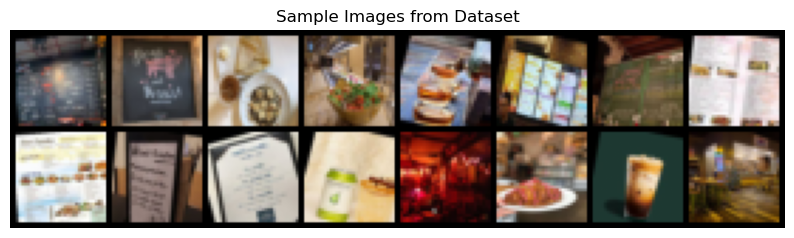

In [3]:
images, labels = next(iter(dataloader))
images = images[:16] * 0.5 + 0.5  # De-normalize

plt.figure(figsize=(10, 5))
plt.axis("off")
plt.title("Sample Images from Dataset")
plt.imshow(vutils.make_grid(images, nrow=8).permute(1, 2, 0))
plt.show()


## Define the Improved Conditional UNet for DDPM

### Timestep Embedding

In [4]:
import torch.nn as nn
import torch.nn.functional as F

def get_timestep_embedding(timesteps, dim):
    half_dim = dim // 2
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -(torch.log(torch.tensor(10000.0)) / (half_dim - 1)))
    emb = timesteps[:, None] * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    return emb  # shape: [B, dim]


### Residual Block (with timestep and label conditioning)

In [5]:
class ConditionalResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.time_emb_proj = nn.Linear(emb_dim, out_ch)
        self.label_emb_proj = nn.Linear(emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.BatchNorm2d(out_ch)
        self.norm2 = nn.BatchNorm2d(out_ch)
        self.act = nn.SiLU()

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb, y_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h += self.time_emb_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h += self.label_emb_proj(y_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.skip(x)


### Full Conditional UNet

In [6]:
class ConditionalUNet(nn.Module):
    def __init__(self, num_classes, img_channels=3, base_channels=64, time_emb_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )
        self.label_emb = nn.Embedding(num_classes, time_emb_dim)

        self.enc1 = ConditionalResBlock(img_channels, base_channels, time_emb_dim)
        self.enc2 = ConditionalResBlock(base_channels, base_channels*2, time_emb_dim)
        self.enc3 = ConditionalResBlock(base_channels*2, base_channels*4, time_emb_dim)

        self.mid = ConditionalResBlock(base_channels*4, base_channels*4, time_emb_dim)

        self.dec3 = ConditionalResBlock(base_channels*4, base_channels*2, time_emb_dim)
        self.dec2 = ConditionalResBlock(base_channels*2, base_channels, time_emb_dim)
        self.dec1 = ConditionalResBlock(base_channels, img_channels, time_emb_dim)

        self.down = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t, y):
        t_emb = self.time_mlp(get_timestep_embedding(t, self.time_mlp[0].in_features))
        y_emb = self.label_emb(y)

        x1 = self.enc1(x, t_emb, y_emb)
        x2 = self.enc2(self.down(x1), t_emb, y_emb)
        x3 = self.enc3(self.down(x2), t_emb, y_emb)

        x_mid = self.mid(self.down(x3), t_emb, y_emb)

        x = self.up(x_mid)
        x = self.dec3(x + x3, t_emb, y_emb)
        x = self.up(x)
        x = self.dec2(x + x2, t_emb, y_emb)
        x = self.up(x)
        x = self.dec1(x + x1, t_emb, y_emb)

        return x


### Instantiate Model

In [7]:
model = ConditionalUNet(num_classes=num_classes).to(device)
print("Model initialized on", device)

Model initialized on cpu


## Forward Diffusion Process

### Noise Schedule Setup

In [8]:
import numpy as np

# Total diffusion steps
T = 300  # You can tune this later (500, 1000...)

# Linear beta schedule
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


### Forward Diffusion Function

In [9]:
def forward_diffusion_sample(x_0, t):
    """
    Adds noise to x_0 at timestep t.
    Returns x_t and the actual noise.
    """
    noise = torch.randn_like(x_0)
    sqrt_acp_t = sqrt_alphas_cumprod[t][:, None, None, None]
    sqrt_om_acp_t = sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
    x_t = sqrt_acp_t * x_0 + sqrt_om_acp_t * noise
    return x_t, noise


### Visualize Noisy Images Over Time

In [10]:
def show_noisy_samples():
    x, _ = next(iter(dataloader))
    x = x.to(device)[:8]
    steps = [0, 50, 100, 200, 299]
    fig, axes = plt.subplots(1, len(steps), figsize=(15, 3))
    for i, step in enumerate(steps):
        t = torch.full((x.size(0),), step, device=device, dtype=torch.long)
        noisy_x, _ = forward_diffusion_sample(x, t)
        noisy_x = (noisy_x * 0.5 + 0.5).clamp(0, 1)  # de-normalize
        grid = vutils.make_grid(noisy_x, nrow=4)
        axes[i].imshow(grid.permute(1, 2, 0).cpu())
        axes[i].set_title(f"t={step}")
        axes[i].axis("off")
    plt.show()



## Training Loop

### Define Loss & Optimizer

In [11]:
import torch.nn as nn
import torch.optim as optim

# Mean squared error loss
loss_fn = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)


### Training Loop

In [12]:
from tqdm import tqdm

epochs = 100

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        x_0, y = batch
        x_0 = x_0.to(device)
        y = y.to(device)

        # Sample random timestep for each sample in batch
        t = torch.randint(0, T, (x_0.size(0),), device=device).long()

        # Generate noisy image and target noise
        x_t, noise = forward_diffusion_sample(x_0, t)

        # Predict noise from noisy image
        predicted_noise = model(x_t, t, y)

        # Compute loss
        loss = loss_fn(predicted_noise, noise)
        total_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(dataloader)
    print(f">>> Epoch {epoch+1}: Avg Loss = {avg_loss:.4f}")


Epoch 1/100: 100%|██████████| 63/63 [01:19<00:00,  1.26s/it]


>>> Epoch 1: Avg Loss = 0.6209


Epoch 2/100: 100%|██████████| 63/63 [01:12<00:00,  1.15s/it]


>>> Epoch 2: Avg Loss = 0.2835


Epoch 3/100: 100%|██████████| 63/63 [01:09<00:00,  1.10s/it]


...

>>> Epoch 98: Avg Loss = 0.1112


Epoch 99/100: 100%|██████████| 63/63 [01:12<00:00,  1.14s/it]


>>> Epoch 99: Avg Loss = 0.1055


Epoch 100/100: 100%|██████████| 63/63 [01:15<00:00,  1.20s/it]

>>> Epoch 100: Avg Loss = 0.1112


## Sampling from the DDPM Model

### Sampling Function

In [13]:
@torch.no_grad()
def sample_ddpm(model, n_samples, label, img_size=64):
    model.eval()
    x = torch.randn(n_samples, 3, img_size, img_size).to(device)
    y = torch.full((n_samples,), label, device=device, dtype=torch.long)

    for t in reversed(range(T)):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        beta_t = betas[t]
        sqrt_alpha_t = torch.sqrt(alphas[t])
        sqrt_om_acp_t = sqrt_one_minus_alphas_cumprod[t]

        predicted_noise = model(x, t_batch, y)

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / sqrt_alpha_t) * (x - (beta_t / sqrt_om_acp_t) * predicted_noise) + torch.sqrt(beta_t) * noise

    x = x.clamp(-1, 1)
    return (x + 1) / 2  # Scale to [0,1] for display


### Generate and Visualize 1 Image per Class

In [14]:
import matplotlib.pyplot as plt

def generate_per_class(model):
    fig, axes = plt.subplots(1, num_classes, figsize=(15, 4))
    if num_classes == 1:
        axes = [axes]  # make it subscriptable

    for idx, class_name in enumerate(full_dataset.classes):
        img = sample_ddpm(model, n_samples=1, label=idx)
        axes[idx].imshow(img[0].permute(1, 2, 0).cpu())
        axes[idx].set_title(class_name)
        axes[idx].axis("off")
    plt.suptitle("DDPM Generated Images (One Per Class)")
    plt.tight_layout()
    plt.show()


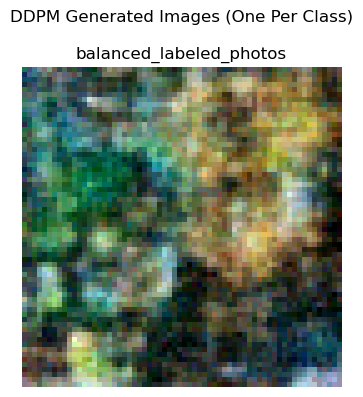

In [15]:
# Run after training
generate_per_class(model)

## Evaluation

### Install & Import TorchMetrics

In [16]:
%pip install torch-fidelity

Note: you may need to restart the kernel to use updated packages.


In [17]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

### Evaluate FID and IS

In [18]:
@torch.no_grad()
def evaluate_fid_and_is(model, real_loader, label_for_gen=0, n_samples=128):
    model.eval()
    fake_imgs = sample_ddpm(model, n_samples=n_samples, label=label_for_gen)
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)

    real_batch, _ = next(iter(real_loader))
    real_uint8 = ((real_batch * 0.5 + 0.5) * 255).to(torch.uint8).to(fake_imgs.device)

    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    isc = InceptionScore(normalize=True).to(device)

    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    isc.update(fake_uint8)

    return fid.compute().item(), isc.compute()[0].item()


In [19]:
fid_score, is_score = evaluate_fid_and_is(model, dataloader, label_for_gen=0)
print(f"FID: {fid_score:.2f}")
print(f"Inception Score: {is_score:.2f}")


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /Users/aesha/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:03<00:00, 28.5MB/s]
/opt/anaconda3/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


FID: 487.78
Inception Score: 1.34


### Confusion Matrix (Classifier-Based)

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_confusion(model, classifier, T):
    y_true, y_pred = [], []

    for label in range(num_classes):
        imgs = sample_ddpm(model, 10, label=label)
        with torch.no_grad():
            logits = classifier(imgs.to(device))
            preds = logits.argmax(1).cpu().tolist()
        y_true.extend([label]*len(preds))
        y_pred.extend(preds)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=dataset.classes)
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title("Confusion Matrix: Generated vs Predicted Labels")
    plt.show()


### GradCAM for Interpretability

In [22]:
%pip install opencv-python==4.7.0.72

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 MB 11.8 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [25]:
import cv2
import numpy as np

def gradcam_on_generated(model, classifier, label):
    img = sample_ddpm(model, 1, label).to(device)
    pred_class = classifier(img).argmax().item()

    features, grads = {}, {}

    def forward_hook(module, input, output): features['value'] = output
    def backward_hook(module, grad_input, grad_output): grads['value'] = grad_output[0]

    # Hook into classifier last conv layer (e.g., layer4 of resnet)
    layer = dict([*classifier.named_modules()])['layer4']
    layer.register_forward_hook(forward_hook)
    layer.register_backward_hook(backward_hook)

    out = classifier(img)
    loss = out[0, pred_class]
    classifier.zero_grad()
    loss.backward()

    fmap = features['value'][0]  # [C, H, W]
    grad = grads['value'][0]
    weights = grad.mean(dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * fmap, dim=0).cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (64, 64))
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)

    img_np = (img[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)
    plt.imshow(overlay)
    plt.title(f"GradCAM for {dataset.classes[label]}")
    plt.axis("off")
    plt.show()


In [26]:
# Run after model is trained and classifier is loaded
gradcam_on_generated(model, classifier, label=2)  # inside, for example


NameError: name 'classifier' is not defined

# LLM Prompts:
1. Provide step by step workflow to implement conditional DDPM model.
2. Write a code to extract dataset from zip file.
3. Provide in step solution from scratch to perform conditional DDPM model from data preparation to model interpretability.